In [ ]:
import colorcet as cc
import gstools as gs
import jax
import matplotlib.pyplot as plt
import numpy as np
from context_flux_no.simulations.pde.euler import Euler2D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField

2026-08-29 20:36:27,083 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [10]:
grf = GaussianRandomField(
    covariance_fns=[
        gs.Gaussian(dim=2, len_scale=0.2),
        gs.Gaussian(dim=2, len_scale=0.2),
        gs.Gaussian(dim=2, len_scale=0.2),
        gs.Gaussian(dim=2, len_scale=0.2),
    ],
    means=[1, 0, 0, 1],
    scales=[0.2, 0.6, 0.6, 0.2],
)

In [11]:
u_test = grf.sample((np.linspace(0, 1, 128), np.linspace(0, 1, 128)), jax.random.key(0))

In [12]:
u_test.shape

(4, 128, 128)

(array([ 18.,  29.,  72.,  92., 107., 148., 157., 160., 173., 189., 171.,
        196., 188., 208., 200., 235., 234., 305., 257., 284., 292., 280.,
        346., 354., 374., 510., 467., 359., 355., 304., 330., 300., 326.,
        298., 310., 333., 357., 347., 303., 332., 325., 307., 295., 255.,
        212., 206., 195., 210., 195., 196., 145., 156., 138., 129., 150.,
        113., 137., 121., 121., 118., 112.,  91.,  80.,  78.,  95.,  69.,
         75.,  79.,  66.,  77.,  71.,  64.,  64.,  72.,  59.,  67.,  64.,
         62.,  60.,  60.,  57.,  58.,  61.,  49.,  63.,  47.,  58.,  53.,
         46.,  54.,  48.,  51.,  49.,  49.,  44.,  31.,  18.,  20.,  19.,
         20.]),
 array([0.0092109 , 0.02411875, 0.03902659, 0.05393444, 0.06884229,
        0.08375013, 0.09865798, 0.11356583, 0.12847368, 0.14338152,
        0.15828937, 0.17319722, 0.18810507, 0.20301291, 0.21792076,
        0.23282861, 0.24773645, 0.2626443 , 0.27755215, 0.29246   ,
        0.30736784, 0.32227569, 0.33718354, 0.

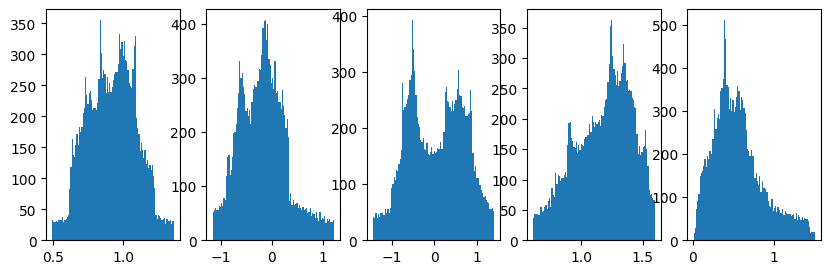

In [13]:
gamma = 1.4
mach = np.hypot(u_test[1], u_test[2]) / np.sqrt(gamma * u_test[3] / u_test[0])

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(u_test.shape[0]):
    axes[i].hist(u_test[i].flatten(), bins=100)
axes[-1].hist(mach.flatten(), bins=100)

In [ ]:
euler_claw = Euler2D(gamma=1.5)
sol_claw = euler_claw.solve(
    lambda xs: grf.sample(xs, key=jax.random.key(10)),
    ((0.0, 1.0), (0.0, 1.0)),
    (128, 128),
    (0.0, 0.5),
    100,
    "periodic",
    use_rho_v_p_ics=True,
)

2026-08-29 20:38:37,173 INFO CLAW: Solution 0 computed for time t=0.000000
2026-08-29 20:38:37,195 INFO CLAW: Solution 1 computed for time t=0.005000
2026-08-29 20:38:37,211 INFO CLAW: Solution 2 computed for time t=0.010000
2026-08-29 20:38:37,227 INFO CLAW: Solution 3 computed for time t=0.015000
2026-08-29 20:38:37,243 INFO CLAW: Solution 4 computed for time t=0.020000
2026-08-29 20:38:37,259 INFO CLAW: Solution 5 computed for time t=0.025000
2026-08-29 20:38:37,275 INFO CLAW: Solution 6 computed for time t=0.030000
2026-08-29 20:38:37,291 INFO CLAW: Solution 7 computed for time t=0.035000
2026-08-29 20:38:37,307 INFO CLAW: Solution 8 computed for time t=0.040000
2026-08-29 20:38:37,323 INFO CLAW: Solution 9 computed for time t=0.045000
2026-08-29 20:38:37,339 INFO CLAW: Solution 10 computed for time t=0.050000
2026-08-29 20:38:37,355 INFO CLAW: Solution 11 computed for time t=0.055000
2026-08-29 20:38:37,370 INFO CLAW: Solution 12 computed for time t=0.060000
2026-08-29 20:38:37,38

In [15]:
sol_claw[0].shape

(101, 4, 128, 128)

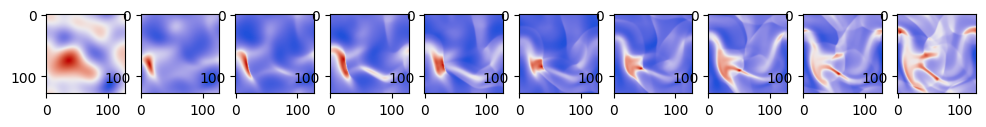

In [16]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol_claw[0][i * 10, 0], cmap=cc.cm.coolwarm)

In [10]:
dataset = generate_dataset(
    dataset_name="2d_euler_test",
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=Euler2D,
    initial_condition_fn=grf.sample,
    coeff_range_dict={"gamma": (1.2, 1.5)},
    x_spans=((0, 1), (0, 1)),
    Nxs=(128, 128),
    t_span=(0, 0.5),
    Nt=100,
    coeff_sampling_strategy="linspace",
    seed=0,
)

  0%|          | 0/10 [00:00<?, ?it/s]/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/zarr/core/group.py:2779: ZarrUserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(
/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/zarr/core/array.py:4480: ZarrUserWarning: Automatic shard shape inference is experimental and may change without notice.
  outer_chunks, inner = resolve_outer_and_inner_chunks(
100%|██████████| 10/10 [04:30<00:00, 27.05s/it]


In [11]:
dataset[10]

{'scalars': {'gamma': array(1.2333333, dtype=float32)},
 't0_fields': {'rho': array([[[1.8836414, 1.9210105, 1.9582238, ..., 1.7733364, 1.8095367,
           1.8463929],
          [1.8935261, 1.9309818, 1.9682649, ..., 1.7828915, 1.8192105,
           1.8561776],
          [1.9030724, 1.9405233, 1.9777907, ..., 1.792405 , 1.828741 ,
           1.8657194],
          ...,
          [1.8530297, 1.8896432, 1.9261825, ..., 1.7453363, 1.7806227,
           1.8166038],
          [1.8632759, 1.9002181, 1.9370538, ..., 1.7544599, 1.7901376,
           1.8264947],
          [1.8735205, 1.9107167, 1.9477789, ..., 1.7638273, 1.799812 ,
           1.836463 ]],
  
         [[1.8641713, 1.8992367, 1.9339739, ..., 1.7595958, 1.7940927,
           1.8290384],
          [1.8763814, 1.9115189, 1.9463023, ..., 1.7714603, 1.8061008,
           1.8411539],
          [1.8883792, 1.9235132, 1.9582785, ..., 1.7830911, 1.8179079,
           1.8531221],
          ...,
          [1.827563 , 1.8621691, 1.8963298, 

In [12]:
await dataset.root.store.getsize_prefix("") / 1e9

1.958427747

In [13]:
dataset.root.tree()

/
├── dimensions
│   ├── time (101,) float32
│   ├── x (128,) float32
│   └── y (128,) float32
├── scalars
│   └── gamma (100,) float32
├── t0_fields
│   ├── E (100, 101, 128, 128) float32
│   └── rho (100, 101, 128, 128) float32
├── t1_fields
│   └── m (100, 101, 128, 128, 2) float32
└── t2_fields

In [14]:
np.unique(dataset.root["scalars"]["gamma"][:])

array([1.2      , 1.2333333, 1.2666668, 1.3      , 1.3333335, 1.3666667,
       1.4      , 1.4333334, 1.4666667, 1.5      ], dtype=float32)